##ÁRBOLES DE REGRESIÓN

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
data = pd.read_csv('/content/drive/MyDrive/Machine Learning - Python/Datasets - Machine Learning/boston/Boston.csv')

In [4]:
data.head(10)

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,black,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2
5,0.02985,0.0,2.18,0,0.458,6.430,58.7,6.0622,3,222,18.7,394.12,5.21,28.7
6,0.08829,12.5,7.87,0,0.524,6.012,66.6,5.5605,5,311,15.2,395.60,12.43,22.9
7,0.14455,12.5,7.87,0,0.524,6.172,96.1,5.9505,5,311,15.2,396.90,19.15,27.1
8,0.21124,12.5,7.87,0,0.524,5.631,100.0,6.0821,5,311,15.2,386.63,29.93,16.5
9,0.17004,12.5,7.87,0,0.524,6.004,85.9,6.5921,5,311,15.2,386.71,17.10,18.9


In [5]:
data.shape

(506, 14)

In [6]:
colnames = data.columns.values.tolist()
predictors = colnames[:13]
target = colnames[13]
X = data[predictors]
Y = data[target]

In [7]:
regtree = DecisionTreeRegressor(min_samples_split=30, min_samples_leaf=10, random_state=0)

In [8]:
regtree.fit(X,Y)

DecisionTreeRegressor(min_samples_leaf=10, min_samples_split=30, random_state=0)

In [9]:
from sklearn.tree import DecisionTreeClassifier, plot_tree

In [10]:
preds = regtree.predict(data[predictors])
data['preds'] = preds

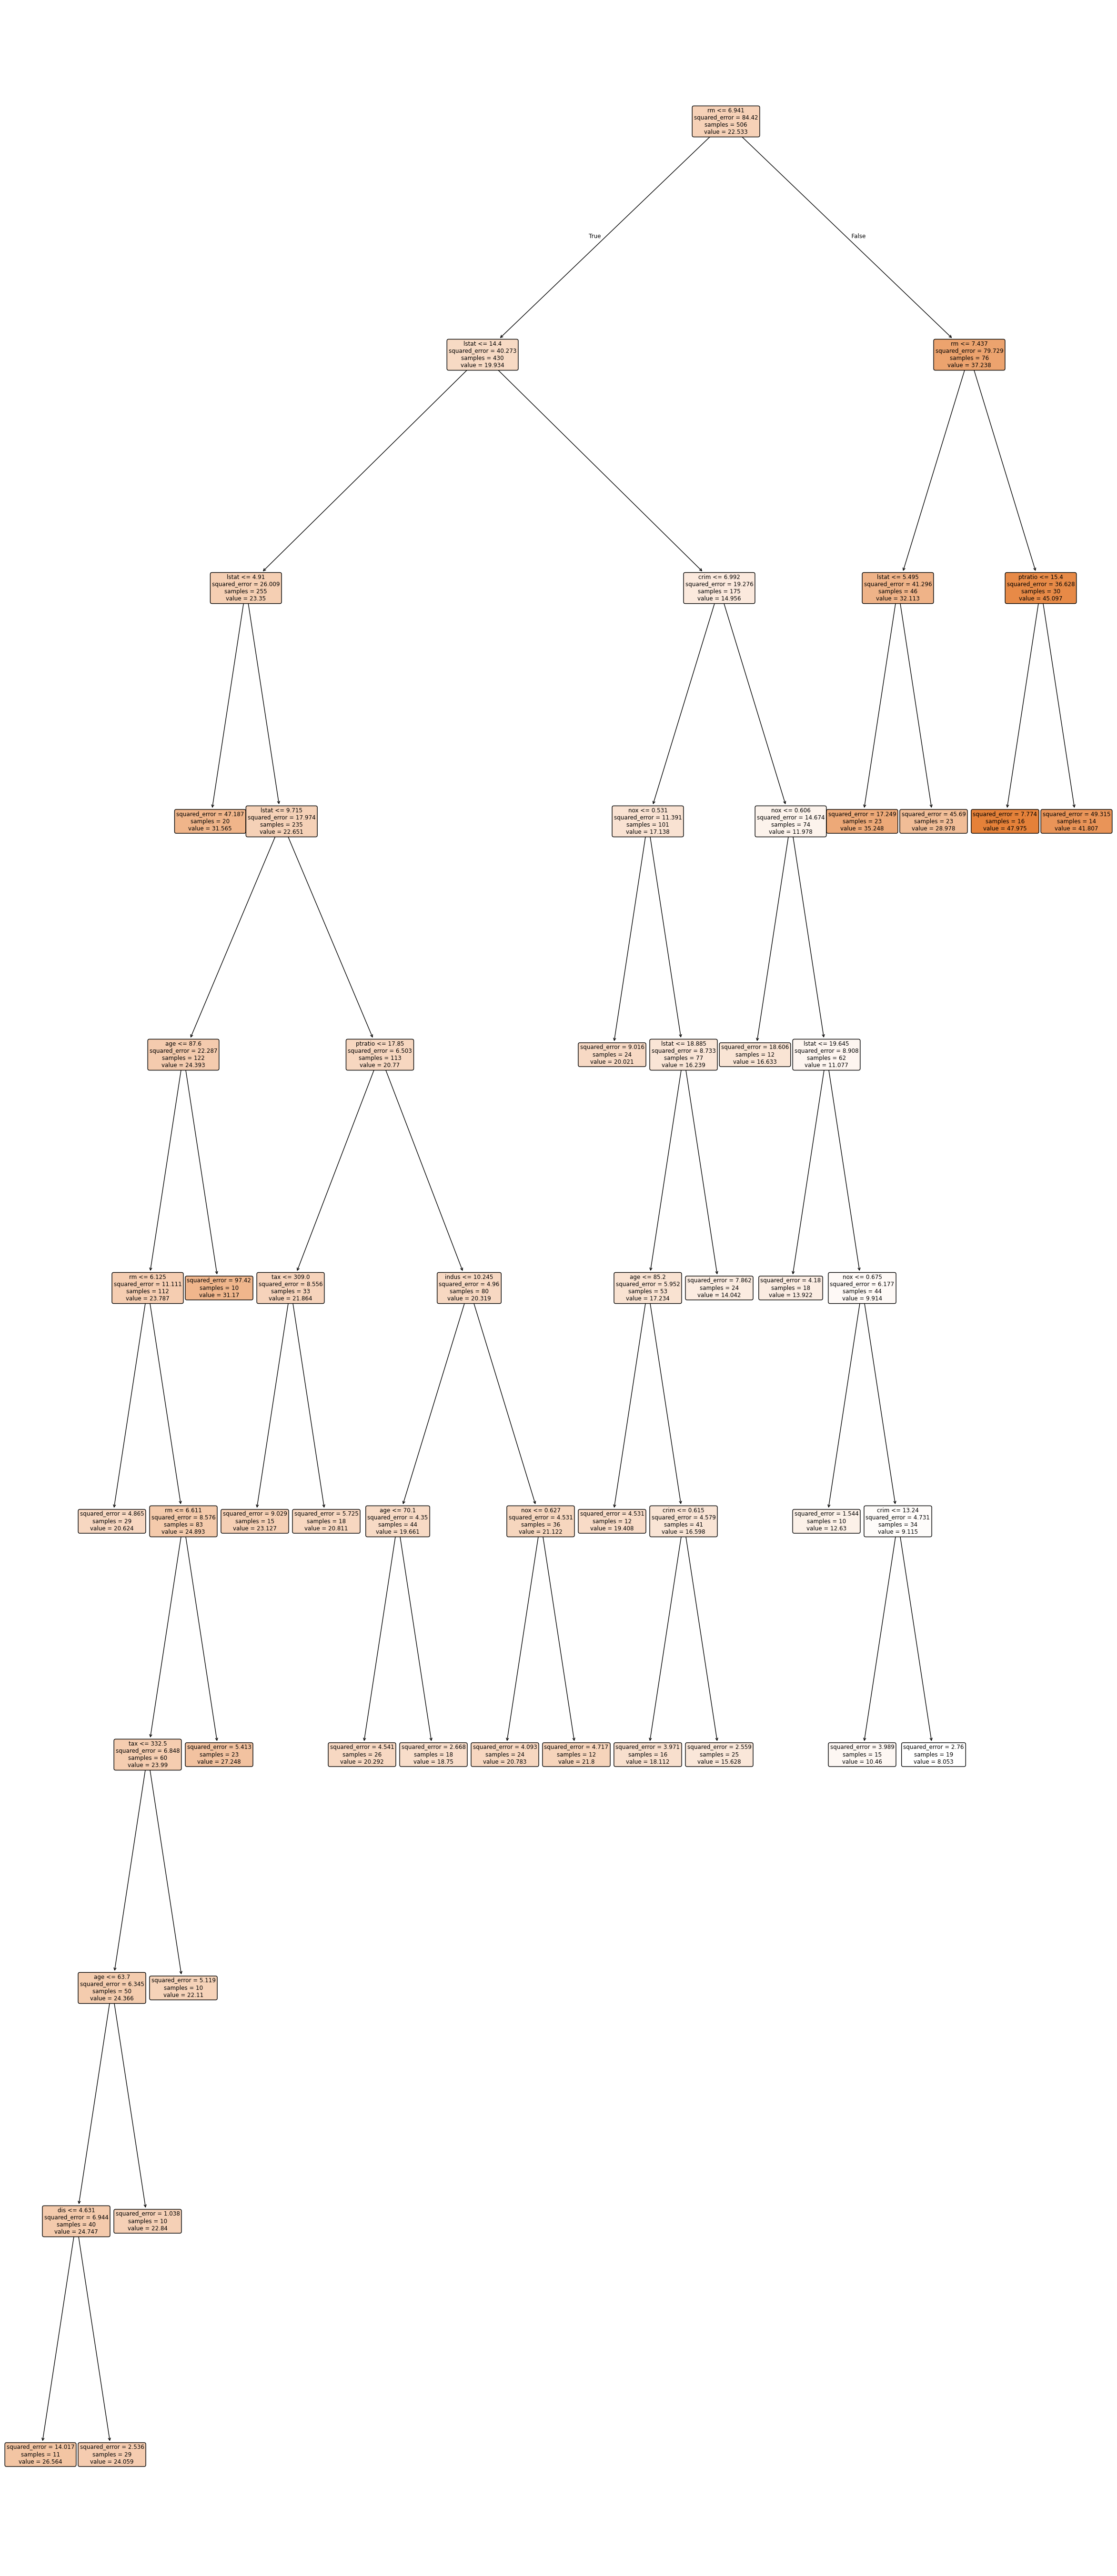

In [11]:
plt.figure(figsize = (30, 70))  # Ajusta el tamaño del gráfico según necesites
plot_tree(regtree, feature_names = predictors, filled = True, rounded = True)
plt.show()

##RANDOM FOREST

In [12]:
from sklearn.ensemble import RandomForestRegressor

In [23]:
forest = RandomForestRegressor(n_jobs = 2, oob_score = True, n_estimators = 10000)
forest.fit(X,Y)

RandomForestRegressor(n_estimators=10000, n_jobs=2, oob_score=True)

In [24]:
forest.oob_prediction_

array([28.50850213, 22.63456587, 34.44368879, 34.77815427, 34.2844602 ,
       24.05749791, 20.26489303, 17.26843407, 17.69799175, 19.65672058,
       20.72335526, 20.837776  , 21.27450232, 20.05018767, 19.97306843,
       20.36740802, 21.42826442, 18.29492934, 18.64694429, 19.78853712,
       14.51134049, 18.58644159, 16.12770106, 15.04205531, 16.64923622,
       15.75836502, 17.41327362, 15.19797149, 20.04794521, 23.01640969,
       14.7375344 , 19.6539056 , 16.6131766 , 14.64445047, 14.33536819,
       21.01271989, 20.86510159, 20.90848599, 21.04663184, 28.12398252,
       33.86752606, 30.89140518, 24.44057813, 24.52695675, 21.93447991,
       19.77674482, 20.17525883, 19.72229544, 18.6711003 , 19.51032926,
       20.78521953, 21.99630522, 25.53674699, 20.70217155, 19.37583948,
       33.95379627, 22.9802771 , 31.0299316 , 22.97237599, 20.4779675 ,
       18.97942122, 19.24885201, 24.09640929, 25.78699783, 32.41482187,
       24.67762387, 20.1296918 , 20.56482439, 19.38578595, 20.94

Con la linea anterior, no hacemos nada. Agregemos esta información como columna a nuestro dataset de estudio:

In [25]:
data['rforest_pred'] = forest.oob_prediction_

In [26]:
#vamos a visualizar la columna del target y esta nueva columna, a modo de comparación:
data[['rforest_pred', 'medv']]

,rforest_pred,medv
0,28.508502,24.0
1,22.634566,21.6
2,34.443689,34.7
3,34.778154,33.4
4,34.284460,36.2
...,...,...
501,24.218474,22.4
502,19.032392,20.6
503,27.770996,23.9
504,26.272237,22.0


In [27]:
#Calculemos el error cudrático medio:

data['rforest_error2'] = (data['rforest_pred'] - data['medv'])**2

sum(data['rforest_error2'])/len(data)

10.174689206961922

In [28]:
forest.oob_score_

0.8794747370130681